Scanning base: /Users/sebastiankalos/Documents/OXFORD/HerriottCell/250813_HC_NF
Found candidate folders:
  - 10W: 10 TIFF(s)
  - 20W: 10 TIFF(s)
  - 30W: 10 TIFF(s)
  - 40W: 10 TIFF(s)
  - 50W: 14 TIFF(s)
  - 60W: 10 TIFF(s)


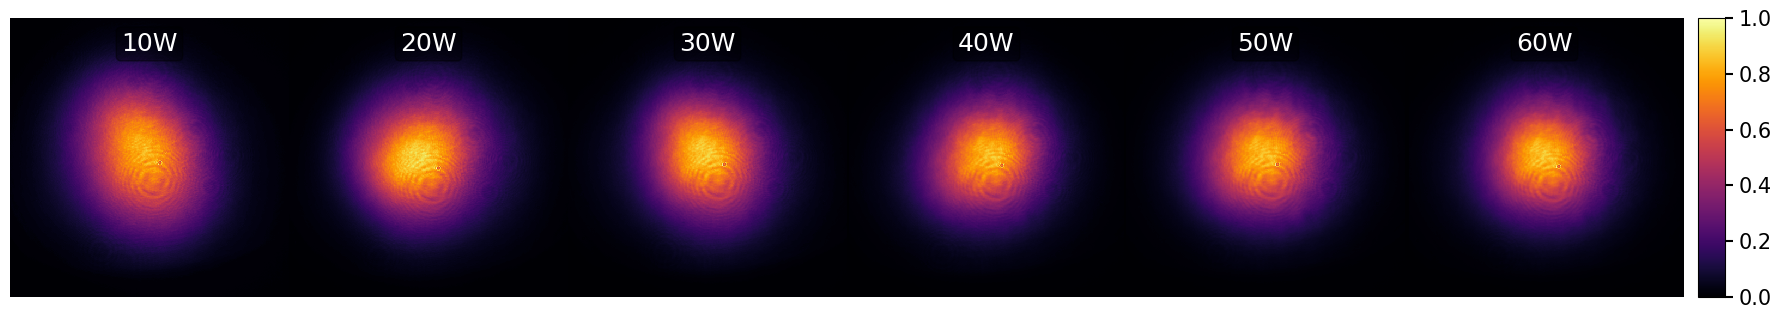

In [31]:
import os, glob, re, sys
import numpy as np
import matplotlib.pyplot as plt

try:
    import tifffile as tiff
    _HAS_TIFFFILE = True
except ImportError:
    _HAS_TIFFFILE = False
    from PIL import Image

# ---------- Utilities ----------
def natural_key(s: str):
    return [int(text) if text.isdigit() else text.lower() for text in re.split(r'(\d+)', s)]

def read_tiff_stack(path: str) -> np.ndarray:
    if _HAS_TIFFFILE:
        arr = tiff.imread(path)
        arr = np.asarray(arr)
        if arr.ndim == 3:
            arr = arr.mean(axis=0)
        elif arr.ndim == 4:
            arr = arr.mean(axis=(0, 3))
        return arr.astype(np.float64, copy=False)
    else:
        im = Image.open(path).convert("I")
        return np.array(im, dtype=np.float64)

def robust_background_level(img: np.ndarray, pct: float = 5.0) -> float:
    return float(np.percentile(img, pct))

def intensity_centroid(img: np.ndarray):
    img = np.nan_to_num(img, nan=0.0)
    if img.min() < 0:
        img = img - img.min()
    total = img.sum()
    if total <= 0:
        h, w = img.shape
        return h/2, w/2
    y_idx, x_idx = np.indices(img.shape)
    cy = (img * y_idx).sum() / total
    cx = (img * x_idx).sum() / total
    return cy, cx

def second_moments(img, cy, cx):
    if img.min() < 0:
        img = img - img.min()
    total = img.sum()
    if total <= 0:
        h, w = img.shape
        return h/6, w/6
    y_idx, x_idx = np.indices(img.shape)
    dy2 = ((y_idx - cy)**2 * img).sum() / total
    dx2 = ((x_idx - cx)**2 * img).sum() / total
    return np.sqrt(dy2), np.sqrt(dx2)

def square_crop_bounds(h, w, cy, cx, half):
    cy, cx = int(round(cy)), int(round(cx))
    y0, y1 = max(0, cy-half), min(h, cy+half)
    x0, x1 = max(0, cx-half), min(w, cx+half)
    return y0, y1, x0, x1

def pad_to_square(img, target_size):
    h, w = img.shape
    canvas = np.zeros((target_size, target_size), dtype=img.dtype)
    y0, x0 = (target_size - h)//2, (target_size - w)//2
    canvas[y0:y0+h, x0:x0+w] = img
    return canvas

# ---------- IO helpers ----------
def find_power_folders(base):
    """
    Return subfolders that look like '10W', '20W', etc. Case-insensitive and tolerant of spaces.
    """
    if not os.path.isdir(base):
        raise FileNotFoundError(f"Base path not found: {base}")
    candidates = []
    for entry in os.scandir(base):
        if entry.is_dir():
            name = entry.name.strip()
            if re.search(r"\d+\s*[Ww]$", name):
                candidates.append(entry.path)
    return sorted(candidates, key=natural_key)

def find_tiffs_recursive(folder):
    """
    Recursively find TIFF files under folder.
    """
    patterns = ["**/*.tif", "**/*.tiff", "**/*.TIF", "**/*.TIFF"]
    paths = []
    for pat in patterns:
        paths.extend(glob.glob(os.path.join(folder, pat), recursive=True))
    # Remove duplicates while preserving order
    seen = set(); out = []
    for p in paths:
        if p not in seen:
            seen.add(p); out.append(p)
    return out

# ---------- Processing ----------
def load_and_average(folder):
    paths = find_tiffs_recursive(folder)
    if not paths:
        raise FileNotFoundError(f"No TIFFs found (recursively) in {folder}")
    imgs = [read_tiff_stack(p) for p in sorted(paths)]
    shapes = np.array([im.shape for im in imgs])
    if not np.all(shapes == shapes[0]):
        min_h, min_w = shapes[:,0].min(), shapes[:,1].min()
        imgs = [im[:min_h,:min_w] for im in imgs]
    return np.mean(imgs, axis=0)

def process_folder(folder, k_sigma=3.0, min_crop=64, max_crop=512, normalize="per-image"):
    avg = load_and_average(folder)
    bg = robust_background_level(avg)
    avg_bs = avg - bg
    cy, cx = intensity_centroid(avg_bs)
    sy, sx = second_moments(avg_bs, cy, cx)
    s = max(sy, sx)
    half = int(np.clip(k_sigma*s, min_crop/2, max_crop/2))
    y0, y1, x0, x1 = square_crop_bounds(*avg_bs.shape, cy, cx, half)
    cropped = avg_bs[y0:y1, x0:x1]
    if normalize == "per-image":
        mx = cropped.max()
        if mx > 0:
            cropped = cropped / mx
    return {
        "cropped": cropped,
        "centroid": (cy, cx),
        "sigma": (sy, sx),
        "label": os.path.basename(folder)
    }

def plot_side_by_side(results, normalize="per-image", cmap="inferno"):
    if not results:
        print("No results to plot.")
        return
    cropped = [r["cropped"] for r in results]
    labels  = [r["label"]   for r in results]

    pairs = [(c, l) for c, l in zip(cropped, labels) if c.size > 0]
    if not pairs:
        print("All cropped images are empty after processing.")
        return
    cropped, labels = zip(*pairs)

    target = max(c.shape[0] for c in cropped)
    padded = [pad_to_square(c, target) if c.shape[0]!=target else c for c in cropped]

    if normalize == "global":
        gmax = max(float(c.max()) for c in padded)
        if gmax > 0:
            padded = [c/gmax for c in padded]

    n = len(padded)
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
    if n == 1:
        axes = [axes]

    im = None
    for ax, img, lbl in zip(axes, padded, labels):
        im = ax.imshow(img, origin="lower", cmap=cmap, interpolation="nearest")
        ax.axis("off")
        ax.text(
            0.5, 0.95, lbl,
            transform=ax.transAxes,
            ha="center", va="top",
            color="white", fontsize=18,
            bbox=dict(facecolor="black", alpha=0.4, boxstyle="round,pad=0.2")
        )

        # ---- shared colorbar that matches the right-most image height, without resizing it ----
    # leave a little right margin for the colorbar
    plt.subplots_adjust(wspace=0, hspace=0, left=0, right=0.93, bottom=0, top=1)

    # position of the last image axes in figure coordinates
    bbox = axes[-1].get_position()
    cbar_width = 0.015   # figure fraction
    pad = 0.008          # gap between last image and colorbar (figure fraction)

    # colorbar axis: same vertical span as the last image; placed just to its right
    cax_left = bbox.x1 + pad
    # colorbar axis
    cax = fig.add_axes([cax_left, bbox.y0, cbar_width, bbox.height])
    cb = fig.colorbar(im, cax=cax)

    # --- customize ticks/labels ---
    cb.ax.tick_params(labelsize=15, length=6, width=1.5)  # fontsize + tick length/width





# ---------- Run ----------
base = "/Users/sebastiankalos/Documents/OXFORD/HerriottCell/250813_HC_NF"
print(f"Scanning base: {base}")

power_folders = find_power_folders(base)
if not power_folders:
    print("No subfolders like '10W' found under the base directory.\n"
          "Tips:\n"
          " - Check the path\n"
          " - Ensure folders are named like 10W, 20W, ... (case-insensitive)\n"
          " - Or adjust the folder detection regex in find_power_folders()\n")
else:
    print("Found candidate folders:")
    for f in power_folders:
        n = len(find_tiffs_recursive(f))
        print(f"  - {os.path.basename(f)}: {n} TIFF(s)")

results = []
for folder in power_folders:
    try:
        if len(find_tiffs_recursive(folder)) == 0:
            print(f"[skip] {os.path.basename(folder)} has no TIFFs.")
            continue
        res = process_folder(folder, k_sigma=3.0, min_crop=64, max_crop=512, normalize="per-image")
        results.append(res)
    except Exception as e:
        print(f"[WARN] Skipping {os.path.basename(folder)}: {e}")

if not results:
    print("\nNothing to plot — all folders were empty or failed to load.\n"
          "If your shots are saved with different extensions or deeper nesting, they should still be picked up.\n"
          "If not, check read permissions and file integrity.")
else:
    plot_side_by_side(results, normalize="per-image")

plt.savefig('/Users/sebastiankalos/Documents/OXFORD/Thesis_writeup/images/plots/HC_NF.png',bbox_inches='tight',dpi=300)


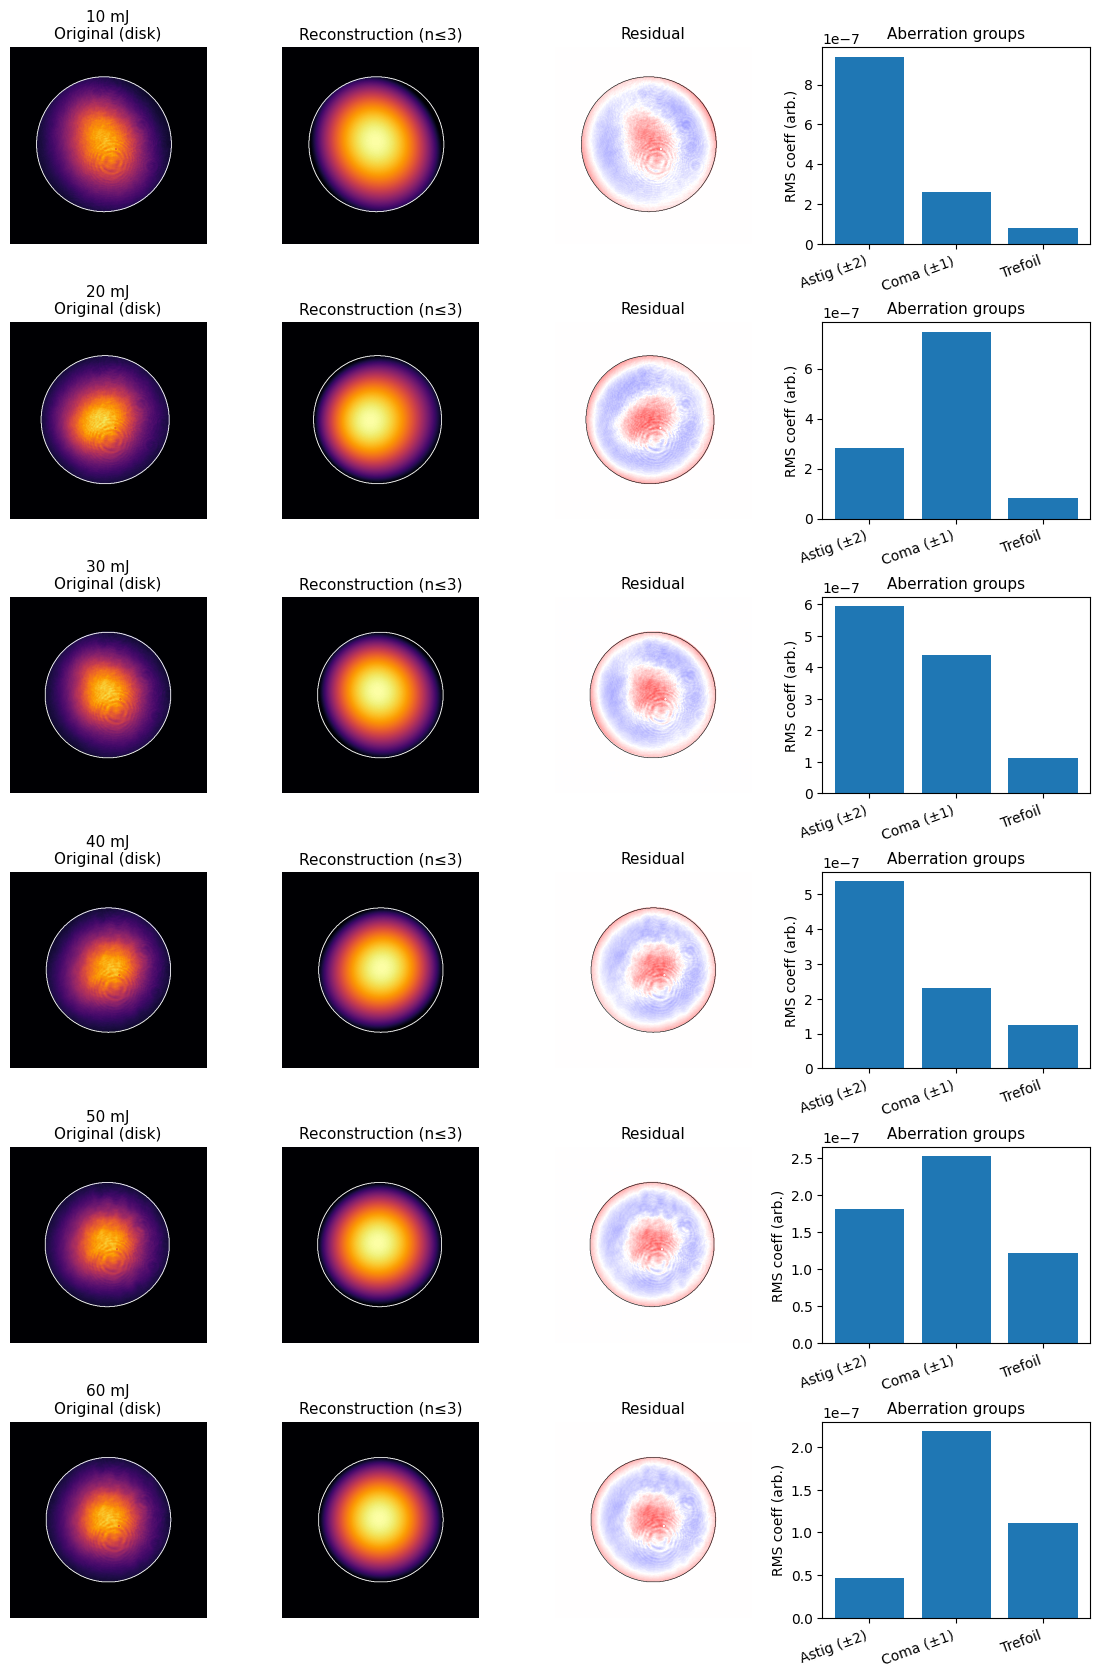

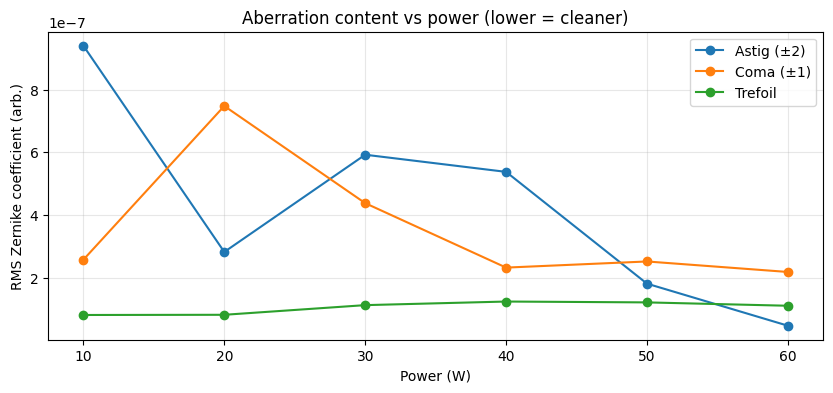


=== Top Zernike coefficients per beam (|n|<=3) ===
     10W -> Z(0,0):+1.030e-05  |  Z(2,0):-5.823e-06  |  Z(2,-2):-7.445e-07  |  Z(2,2):-5.744e-07  |  Z(3,-1):-2.574e-07  |  Z(1,1):-1.376e-07  |  Z(1,-1):+1.246e-07  |  Z(3,3):+6.635e-08  |  Z(3,-3):-4.653e-08  |  Z(3,1):-4.119e-09
     20W -> Z(0,0):+1.142e-05  |  Z(2,0):-6.690e-06  |  Z(3,1):+7.435e-07  |  Z(1,1):-5.844e-07  |  Z(2,-2):+2.636e-07  |  Z(2,2):+1.006e-07  |  Z(3,-1):+8.177e-08  |  Z(3,3):-6.413e-08  |  Z(3,-3):+5.055e-08  |  Z(1,-1):+2.949e-08
     30W -> Z(0,0):+1.187e-05  |  Z(2,0):-7.102e-06  |  Z(2,-2):-5.399e-07  |  Z(3,-1):-3.469e-07  |  Z(3,1):+2.673e-07  |  Z(2,2):-2.441e-07  |  Z(1,1):-1.823e-07  |  Z(1,-1):+1.819e-07  |  Z(3,3):+8.826e-08  |  Z(3,-3):+6.973e-08
     40W -> Z(0,0):+1.250e-05  |  Z(2,0):-7.475e-06  |  Z(2,-2):+5.310e-07  |  Z(3,-1):-1.937e-07  |  Z(1,-1):+1.393e-07  |  Z(3,1):-1.282e-07  |  Z(3,-3):-1.184e-07  |  Z(2,2):+8.472e-08  |  Z(3,3):-3.687e-08  |  Z(1,1):+3.631e-08
     50W -> Z(0,0):+

In [33]:
# Zernike decomposition up to TREFOIL (n <= 3), excluding spherical (n=4, m=0)

import numpy as np
import matplotlib.pyplot as plt
import re
from math import factorial

# --------------------------
# Zernike machinery
# --------------------------
def zernike_radial(n, m, rho):
    m = abs(m)
    if (n - m) % 2 != 0:
        return np.zeros_like(rho)
    R = np.zeros_like(rho, dtype=np.float64)
    kmax = (n - m) // 2
    for k in range(kmax + 1):
        num = (-1)**k * factorial(n - k)
        den = factorial(k) * factorial((n + m)//2 - k) * factorial((n - m)//2 - k)
        R += (num / den) * rho**(n - 2*k)
    return R

def zernike_nm(n, m, rho, theta):
    # Orthonormal on unit disk under ρ dρ dθ
    if m == 0:
        return np.sqrt(n+1) * zernike_radial(n, 0, rho)
    elif m > 0:
        return np.sqrt(2*(n+1)) * zernike_radial(n, m, rho) * np.cos(m*theta)
    else:
        return np.sqrt(2*(n+1)) * zernike_radial(n, -m, rho) * np.sin((-m)*theta)

def zernike_list(N_max):
    pairs = []
    for n in range(N_max+1):
        for m in range(-n, n+1, 2):
            pairs.append((n, m))
    return pairs

def build_zernike_basis(shape, center, radius_pix, N_max, mask=None):
    h, w = shape
    cy, cx = center
    y, x = np.indices((h, w))
    dx = x - cx
    dy = y - cy
    rho = np.sqrt(dx*dx + dy*dy) / (radius_pix + 1e-12)
    theta = np.arctan2(dy, dx)

    disk = rho <= 1.0
    if mask is not None:
        disk = disk & mask

    pairs = zernike_list(N_max)
    K = len(pairs)
    A = np.zeros((h, w, K), dtype=np.float64)
    for k, (n, m) in enumerate(pairs):
        A[:, :, k] = zernike_nm(n, m, rho, theta)

    idx = np.where(disk)
    A_masked = A[idx[0], idx[1], :]
    return A_masked, pairs, disk, (rho, theta)

def power_from_label(lbl):
    m = re.search(r'(\d+)\s*[Ww]', lbl or "")
    return int(m.group(1)) if m else np.nan

# --------------------------
# Beam-to-disk mapping
# --------------------------
def image_center_and_radius(img, k_radius=2.0):
    I = np.asarray(img, float)
    I = I - I.min()
    S = I.sum()
    h, w = I.shape
    if S <= 0:
        return (h-1)/2.0, (w-1)/2.0, min(h, w)/3.0
    y, x = np.indices((h, w))
    cy = (I*y).sum()/S
    cx = (I*x).sum()/S
    dy = y - cy
    dx = x - cx
    var_x = (I*dx*dx).sum()/S
    var_y = (I*dy*dy).sum()/S
    sigma_x = np.sqrt(max(var_x, 1e-12))
    sigma_y = np.sqrt(max(var_y, 1e-12))
    R = k_radius * 0.5*(sigma_x + sigma_y)
    return cy, cx, R

# --------------------------
# Config: up to TREFOIL (n <= 3), exclude spherical
# --------------------------
N_MAX = 3         # includes piston, tilt, defocus, astig, coma, trefoil — but NOT spherical (n=4)
K_RADIUS = 2.0    # unit-disk radius ≈ 2 * avg sigma (tweak if needed)

# Groups to summarize (no spherical here)
SELECTED = {
    "Astig (±2)": [(2,  2), (2, -2)],
    "Coma (±1)":  [(3,  1), (3, -1)],
    "Trefoil":    [(3,  3), (3, -3)],
}

# --------------------------
# Guard
# --------------------------
if 'results' not in globals() or len(results) == 0:
    raise RuntimeError("No `results` found. Run the averaging/cropping step first.")

ordered = sorted(results, key=lambda r: power_from_label(r.get('label','')))

# --------------------------
# Decomposition
# --------------------------
per_beam = []
for res in ordered:
    img = np.asarray(res['cropped'], float)
    img = img - img.min()
    if img.max() > 0:
        img = img / img.max()

    cy, cx, R = image_center_and_radius(img, k_radius=K_RADIUS)

    A_masked, pairs, disk_mask, _ = build_zernike_basis(img.shape, (cy, cx), R, N_MAX)

    b = img[disk_mask].astype(np.float64)
    s = b.sum()
    if s > 0:
        b = b / s

    c, *_ = np.linalg.lstsq(A_masked, b, rcond=None)

    rec = (A_masked @ c)
    rec_img = np.zeros_like(img)
    rec_img[disk_mask] = rec
    rec_img_disp = rec_img / (rec_img.max() + 1e-12)

    resid = np.zeros_like(img)
    resid[disk_mask] = b - rec

    coeff_map = {pairs[k]: c[k] for k in range(len(pairs))}
    groups = {name: float(np.sqrt(np.sum([coeff_map.get(nm, 0.0)**2 for nm in nm_list])))
              for name, nm_list in SELECTED.items()}

    per_beam.append({
        "label": res.get("label", "beam"),
        "power_W": power_from_label(res.get("label","")),
        "coeffs": c,
        "pairs": pairs,
        "img": img,
        "disk_mask": disk_mask,
        "recon": rec_img_disp,
        "resid": resid,
        "groups": groups,
        "center": (cy, cx),
        "R": R
    })

# --------------------------
# Visualization: per-beam panels
# --------------------------
rows = len(per_beam)
fig = plt.figure(figsize=(14, 3.4*rows))
gs = fig.add_gridspec(rows, 4, width_ratios=[1,1,1,1.3], wspace=0.30, hspace=0.40)

def label_to_mJ(lbl):
    m = re.search(r"(\d+)\s*[Ww]$", lbl or "")
    return f"{m.group(1)} mJ" if m else lbl

for i, B in enumerate(per_beam):
    img = B["img"]; recon = B["recon"]; resid = B["resid"]; mask = B["disk_mask"]
    title = label_to_mJ(B["label"])

    ax0 = fig.add_subplot(gs[i,0])
    disp0 = np.zeros_like(img); disp0[mask] = img[mask]
    ax0.imshow(disp0, origin="lower", cmap="inferno", vmin=0, vmax=1)
    ax0.contour(mask, levels=[0.5], colors="white", linewidths=0.6)
    ax0.set_title(f"{title}\nOriginal (disk)", fontsize=11)
    ax0.axis("off")

    ax1 = fig.add_subplot(gs[i,1])
    ax1.imshow(recon, origin="lower", cmap="inferno", vmin=0, vmax=1)
    ax1.contour(mask, levels=[0.5], colors="white", linewidths=0.6)
    ax1.set_title("Reconstruction (n≤3)", fontsize=11)
    ax1.axis("off")

    ax2 = fig.add_subplot(gs[i,2])
    res = np.zeros_like(img); res[mask] = resid[mask]
    vmax = np.max(np.abs(res[mask])) if np.any(mask) else 1.0
    ax2.imshow(res, origin="lower", cmap="bwr", vmin=-vmax, vmax=vmax)
    ax2.contour(mask, levels=[0.5], colors="k", linewidths=0.4)
    ax2.set_title("Residual", fontsize=11)
    ax2.axis("off")

    ax3 = fig.add_subplot(gs[i,3])
    names = list(SELECTED.keys())
    vals = [B["groups"][nm] for nm in names]
    ax3.bar(range(len(names)), vals)
    ax3.set_xticks(range(len(names)))
    ax3.set_xticklabels(names, rotation=20, ha="right")
    ax3.set_ylabel("RMS coeff (arb.)")
    ax3.set_title("Aberration groups", fontsize=11)

plt.show()

# --------------------------
# Trends vs power (Astig, Coma, Trefoil)
# --------------------------
powers = np.array([B["power_W"] for B in per_beam])
valid = ~np.isnan(powers)
if np.any(valid):
    powers_v = powers[valid]
    group_names = list(SELECTED.keys())
    mat = np.stack([[per_beam[i]["groups"][g] for g in group_names] for i in range(len(per_beam))], axis=0)[valid]

    fig, ax = plt.subplots(figsize=(10,4))
    for j, g in enumerate(group_names):
        ax.plot(powers_v, mat[:, j], marker='o', label=g)
    ax.set_xlabel("Power (W)")
    ax.set_ylabel("RMS Zernike coefficient (arb.)")
    ax.set_title("Aberration content vs power (lower = cleaner)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()
else:
    print("(Skipped trend plot: couldn’t parse power from labels.)")

# --------------------------
# Print top coefficients per beam (by magnitude), n<=3 only
# --------------------------
def nm_to_str(nm): return f"Z({nm[0]},{nm[1]})"
TOP = 12
print("\n=== Top Zernike coefficients per beam (|n|<=3) ===")
for B in per_beam:
    c = B["coeffs"]; pairs = B["pairs"]
    idx = np.argsort(np.abs(c))[::-1][:TOP]
    items = [f"{nm_to_str(pairs[k])}:{c[k]:+.3e}" for k in idx]
    print(f"{B['label']:>8s} -> " + "  |  ".join(items))
